In [22]:
# Define paths
csv_data_path = '../data/'

In [23]:
import pandas as pd
df = pd.read_csv(csv_data_path + 'pre_cross_val_ml_dataset.csv')
print(df.head())

          Pokemon         Ability_1 Ability_2 Ability_3  Hazard  Pivot  Setup  \
0        koraidon  Orichalcum Pulse       NaN       NaN       0      1      1   
1  zacian-crowned    Intrepid Sword       NaN       NaN       0      0      1   
2          kyogre           Drizzle       NaN       NaN       0      0      1   
3          arceus         Multitype       NaN       NaN       0      0      1   
4           ho-oh       Regenerator  Pressure       NaN       0      0      0   

   Recovery  Utility  Priority  TypeDefScore  TypeOffScore  SpeedTier  \
0         0        0         0           4.0          15.5          1   
1         0        0         0          36.5          13.0          1   
2         0        1         0          12.0           6.0          3   
3         1        1         1          11.0          -0.5          2   
4         1        1         0          16.0          14.0          3   

   PhysBulk  SpeBulk  AtkToSpaRatio  WastedStatRatio   Tier  
0     11500 

In [24]:
from sklearn.model_selection import train_test_split

tier_map = {
    "Ubers": 0,
    "OU": 1,
    "UU": 2,
    "RU": 3,
    "NU": 4,
    "PU": 5,
    "ZU": 6
}

y = df['Tier'].map(tier_map)
X = df.drop(columns=['Tier'])

X_train_cv, X_holdout, y_train_cv, y_holdout = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train_cv = X_train_cv.copy()
X_holdout = X_holdout.copy()
y_train_cv = y_train_cv.copy()
y_holdout = y_holdout.copy()

In [25]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

baseline_model = DummyClassifier(strategy="most_frequent")

baseline_results = cross_validate(
    baseline_model,
    X_train_cv,
    y_train_cv,
    cv=5,
    scoring=['accuracy', 'f1_macro']
)

print(f"Baseline Accuracy: {baseline_results['test_accuracy'].mean():.4f}")
print(f"Baseline F1 (Macro): {baseline_results['test_f1_macro'].mean():.4f}")

Baseline Accuracy: 0.4167
Baseline F1 (Macro): 0.0840


#XGBoost Attempt

#Hyper Parameter Tuning

In [26]:
import optuna
print("Optuna Version", optuna.__version__)

Optuna Version 4.8.0


In [27]:
impactful_abilities = ['Intimidate', 'Magic Guard', 'Prankster', 'Drizzle', 'Drought', 'Huge Power', 'Magic Bounce', 'Snow Warning', 'Guts',
                       'Regenerator', 'Speed Boost', 'Unaware', 'Technician'
                       ]
print(impactful_abilities)

['Intimidate', 'Magic Guard', 'Prankster', 'Drizzle', 'Drought', 'Huge Power', 'Magic Bounce', 'Snow Warning', 'Guts', 'Regenerator', 'Speed Boost', 'Unaware', 'Technician']


In [28]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def objective_xgb(trial):
    param = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "n_estimators": trial.suggest_int("n_estimators", 10, 600),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "eval_metric": "mlogloss",
        "random_state": 42,
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for tr, va in skf.split(X_train_cv, y_train_cv):
        X_train, X_test = X_train_cv.iloc[tr].copy(), X_train_cv.iloc[va].copy()
        y_train, y_test = y_train_cv.iloc[tr], y_train_cv.iloc[va]


        ability_cols = ['Ability_1', 'Ability_2', 'Ability_3']

        abilities_in_fold = set(X_train[ability_cols].values.ravel())

        abilities_to_encode = [a for a in impactful_abilities if a in abilities_in_fold]

        for ability in abilities_to_encode:
            X_train[f"{ability}"] = X_train[ability_cols].eq(ability).any(axis=1).astype(int)
            X_test[f"{ability}"] = X_test[ability_cols].eq(ability).any(axis=1).astype(int)

        X_train_final = X_train.drop(columns=['Pokemon'] + ability_cols)
        X_test_final = X_test.drop(columns=['Pokemon'] + ability_cols)

        X_train_np = X_train_final.to_numpy(dtype=np.float32)
        X_test_np = X_test_final.to_numpy(dtype=np.float32)
        y_train_np = y_train.to_numpy()
        y_test_np = y_test.to_numpy()

        model = xgb.XGBClassifier(**param)
        model.fit(X_train_np, y_train_np)

        preds_np = model.predict(X_test_np)

        scores.append(f1_score(y_test_np, preds_np, average='macro'))

    return float(np.mean(scores))

In [29]:
study = optuna.create_study(study_name="xgboost_study", direction="maximize")
study.optimize(objective_xgb, n_trials=35, show_progress_bar=True, n_jobs=-1)

[I 2026-05-19 15:34:00,113] A new study created in memory with name: xgboost_study
Best trial: 17. Best value: 0.177084:   3%|▎         | 1/35 [00:02<01:25,  2.52s/it]

[I 2026-05-19 15:34:02,627] Trial 17 finished with value: 0.17708407657830857 and parameters: {'max_depth': 10, 'learning_rate': 0.09317778437498249, 'n_estimators': 18, 'subsample': 0.703083100130192, 'colsample_bytree': 0.6765693774566054, 'min_child_weight': 15, 'gamma': 4.1189644071608775}. Best is trial 17 with value: 0.17708407657830857.


Best trial: 5. Best value: 0.181235:   6%|▌         | 2/35 [00:09<02:54,  5.29s/it] 

[I 2026-05-19 15:34:09,867] Trial 5 finished with value: 0.18123472217619113 and parameters: {'max_depth': 3, 'learning_rate': 0.05418438900729389, 'n_estimators': 88, 'subsample': 0.7877686583646595, 'colsample_bytree': 0.6909811531967143, 'min_child_weight': 15, 'gamma': 3.0325466599591495}. Best is trial 5 with value: 0.18123472217619113.


Best trial: 12. Best value: 0.222173:   9%|▊         | 3/35 [00:10<01:37,  3.06s/it]

...

[I 2026-05-19 15:34:40,059] Trial 23 finished with value: 0.21440041688523456 and parameters: {'max_depth': 7, 'learning_rate': 0.01254782338427501, 'n_estimators': 483, 'subsample': 0.8085928595345724, 'colsample_bytree': 0.7921558521211945, 'min_child_weight': 19, 'gamma': 0.1002612975153272}. Best is trial 10 with value: 0.2589035943446891.
[I 2026-05-19 15:34:40,187] Trial 13 finished with value: 0.24167044595616022 and parameters: {'max_depth': 7, 'learning_rate': 0.03602750909110425, 'n_estimators': 596, 'subsample': 0.5238794137976781, 'colsample_bytree': 0.6696153543900849, 'min_child_weight': 10, 'gamma': 1.4883187707273575}. Best is trial 10 with value: 0.2589035943446891.


Best trial: 10. Best value: 0.258904:  97%|█████████▋| 34/35 [00:40<00:00,  2.02it/s]

[I 2026-05-19 15:34:40,445] Trial 28 finished with value: 0.21271831325892795 and parameters: {'max_depth': 6, 'learning_rate': 0.017299666162767176, 'n_estimators': 552, 'subsample': 0.8382221408367789, 'colsample_bytree': 0.9373499913848073, 'min_child_weight': 13, 'gamma': 2.4913835390270487}. Best is trial 10 with value: 0.2589035943446891.


Best trial: 10. Best value: 0.258904: 100%|██████████| 35/35 [00:41<00:00,  1.18s/it]

[I 2026-05-19 15:34:41,579] Trial 20 finished with value: 0.2545252853206116 and parameters: {'max_depth': 7, 'learning_rate': 0.036884859830933966, 'n_estimators': 587, 'subsample': 0.6751661124774044, 'colsample_bytree': 0.7117875667194379, 'min_child_weight': 13, 'gamma': 0.11861441020746044}. Best is trial 10 with value: 0.2589035943446891.


In [30]:
best_params_xgb = study.best_params
print(f"\nBest parameters: {best_params_xgb}")


Best parameters: {'max_depth': 8, 'learning_rate': 0.07919130206920275, 'n_estimators': 489, 'subsample': 0.7088429341712397, 'colsample_bytree': 0.5432547431979113, 'min_child_weight': 16, 'gamma': 0.771905639210882}


In [31]:
import optuna.visualization as vis

display(vis.plot_param_importances(study))
display(vis.plot_optimization_history(study))

#Model Training

In [32]:
import xgboost as xgb
from sklearn.metrics import f1_score, accuracy_score

# Train using train + val then evaluate on X_holdout i.e. test
ability_cols = ['Ability_1', 'Ability_2', 'Ability_3']
abilities_in_train_set = set(X_train_cv[ability_cols].values.ravel())

abilities_to_encode = [a for a in impactful_abilities if a in abilities_in_train_set]

for ability in abilities_to_encode:
    X_train_cv[f"{ability}"] = X_train_cv[ability_cols].eq(ability).any(axis=1).astype(int)
    X_holdout[f"{ability}"] = X_holdout[ability_cols].eq(ability).any(axis=1).astype(int)

X_train_final = X_train_cv.drop(columns=['Pokemon'] + ability_cols)
X_test_final = X_holdout.drop(columns=['Pokemon'] + ability_cols)

model_xgb = xgb.XGBClassifier(
    objective="multi:softprob",
    random_state=42,
    **best_params_xgb
)

model_xgb.fit(X_train_final, y_train_cv)

preds = model_xgb.predict(X_test_final)
train_preds = model_xgb.predict(X_train_final)

train_acc = accuracy_score(y_train_cv, train_preds)
train_f1 = f1_score(y_train_cv, train_preds, average='macro')

acc = accuracy_score(y_holdout, preds)
f1 = f1_score(y_holdout, preds, average='macro')

print(f"Train Set Accuracy: {train_acc:.4f}")
print(f"Train Set F1 Score: {train_f1:.4f}")

print(f"\nTest Set Accuracy: {acc:.4f}")
print(f"Test Set F1 Score: {f1:.4f}")

Train Set Accuracy: 0.6371
Train Set F1 Score: 0.4420

Test Set Accuracy: 0.4624
Test Set F1 Score: 0.2322


In [33]:
import matplotlib.pyplot as plt

def feature_importance_graph(trained_model, features):
  # 1. Get feature importance
  importances = trained_model.feature_importances_
  indices = np.argsort(importances)

  # 2. Plot it
  plt.figure(figsize=(10, 8))
  plt.title("Feature Importances")
  plt.barh(range(len(indices)), importances[indices], color='b', align='center')
  plt.yticks(range(len(indices)), [features[i] for i in indices])
  plt.xlabel('Relative Importance')
  plt.show()

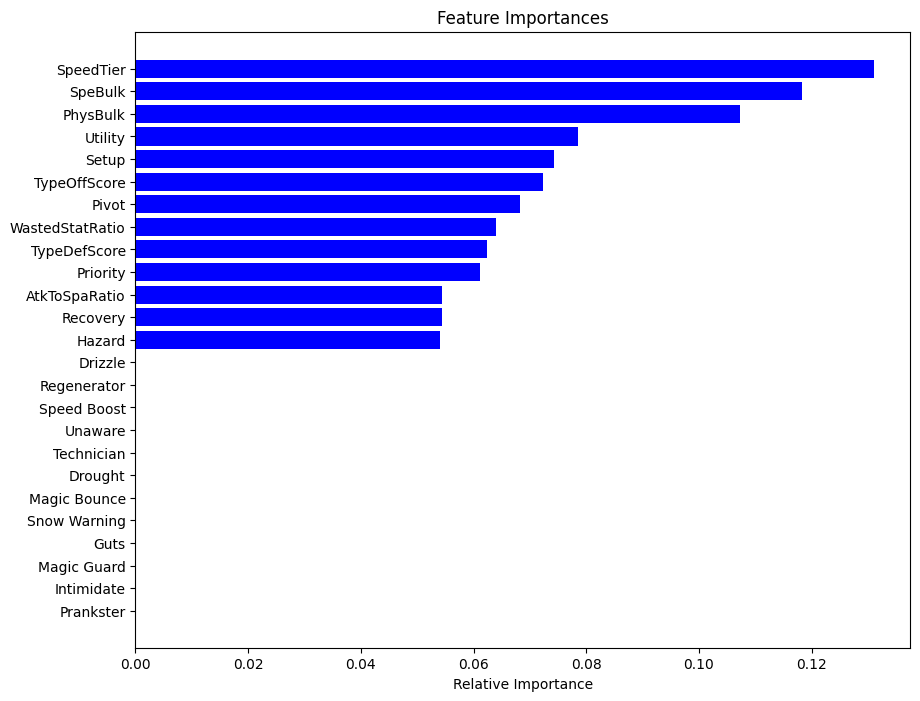

In [34]:
feature_importance_graph(model_xgb, X_train_final.columns)

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def draw_conf_maxtrix(true_labels, predicted_labels):
  # Create the confusion matrix
  cm = confusion_matrix(true_labels, predicted_labels)

  # Set up the display
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tier_map.keys())

  # Plotting
  fig, ax = plt.subplots(figsize=(10, 10))
  disp.plot(cmap='Blues', ax=ax, values_format='d')
  plt.title('Tier Prediction Confusion Matrix')
  plt.show()

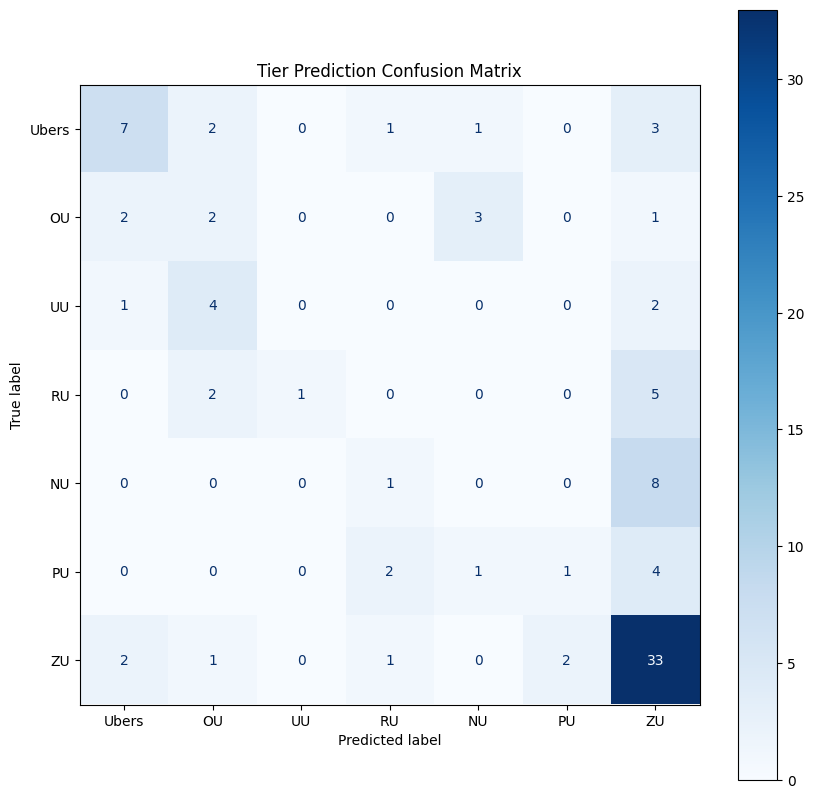

In [36]:
draw_conf_maxtrix(y_holdout, preds)

#SVM Attempt

#Hyperparameter Tuning

In [37]:
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.svm import SVC

numerical_cols = ['TypeDefScore', 'TypeOffScore', 'SpeedTier', 'PhysBulk', 'SpeBulk', 'AtkToSpaRatio', 'WastedStatRatio']

def objective_svm(trial):
    param = {
        "C": trial.suggest_float("C", 0.001, 1000, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear", "poly"]),
        "gamma": trial.suggest_float("gamma", 0.0001, 10, log=True),
        "class_weight": "balanced"
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for tr, va in skf.split(X_train_cv, y_train_cv):
        X_train, X_test = X_train_cv.iloc[tr].copy(), X_train_cv.iloc[va].copy()
        y_train, y_test = y_train_cv.iloc[tr], y_train_cv.iloc[va]

        ability_cols = ['Ability_1', 'Ability_2', 'Ability_3']
        abilities_in_fold = set(X_train[ability_cols].values.ravel())
        abilities_to_encode = [a for a in impactful_abilities if a in abilities_in_fold]

        for ability in abilities_to_encode:
            X_train[f"{ability}"] = X_train[ability_cols].eq(ability).any(axis=1).astype(int)
            X_test[f"{ability}"] = X_test[ability_cols].eq(ability).any(axis=1).astype(int)

        X_train_final = X_train.drop(columns=['Pokemon'] + ability_cols)
        X_test_final = X_test.drop(columns=['Pokemon'] + ability_cols)

        scaler = StandardScaler()
        X_train_num_scaled = scaler.fit_transform(X_train_final[numerical_cols])
        X_test_num_scaled = scaler.transform(X_test_final[numerical_cols])

        categorical_features = [col for col in X_train_final.columns if col not in numerical_cols]
        X_train_bin = X_train_final[categorical_features].to_numpy()
        X_test_bin = X_test_final[categorical_features].to_numpy()

        X_train_prepared = np.hstack([X_train_num_scaled, X_train_bin])
        X_test_prepared = np.hstack([X_test_num_scaled, X_test_bin])

        y_train_np = y_train.to_numpy()
        y_test_np = y_test.to_numpy()

        model = SVC(**param)
        model.fit(X_train_prepared, y_train_np)

        preds = model.predict(X_test_prepared)
        scores.append(f1_score(y_test_np, preds, average='macro'))

    return float(np.mean(scores))

In [38]:
study_svm = optuna.create_study(study_name="svm_study", direction='maximize')
study_svm.optimize(objective_svm, n_trials=35, show_progress_bar=True, n_jobs=-1)

[I 2026-05-19 15:34:42,709] A new study created in memory with name: svm_study
Best trial: 2. Best value: 0.291014:   0%|          | 0/35 [00:02<?, ?it/s]

[I 2026-05-19 15:34:44,824] Trial 5 finished with value: 0.025830305348377637 and parameters: {'C': 122.46134043807629, 'kernel': 'poly', 'gamma': 0.00019265877885810077}. Best is trial 5 with value: 0.025830305348377637.


Best trial: 19. Best value: 0.304874:  17%|█▋        | 6/35 [00:03<00:11,  2.62it/s]

[I 2026-05-19 15:34:45,129] Trial 7 finished with value: 0.2846734981980958 and parameters: {'C': 0.10537594335251779, 'kernel': 'linear', 'gamma': 0.007913462165678054}. Best is trial 7 with value: 0.2846734981980958.
[I 2026-05-19 15:34:45,130] Trial 13 finished with value: 0.06099803894522841 and parameters: {'C': 0.14485126687557645, 'kernel': 'rbf', 'gamma': 0.0031634973863955396}. Best is trial 7 with value: 0.2846734981980958.
[I 2026-05-19 15:34:45,137] Trial 9 finished with value: 0.02821289835112568 and parameters: {'C': 0.007206833416112135, 'kernel': 'poly', 'gamma': 0.00032710575469046166}. Best is trial 7 with value: 0.2846734981980958.
[I 2026-05-19 15:34:45,170] Trial 2 finished with value: 0.2910143523038933 and parameters: {'C': 2.5821269632557082, 'kernel': 'rbf', 'gamma': 0.04509709651595651}. Best is trial 2 with value: 0.2910143523038933.
[I 2026-05-19 15:34:45,369] Trial 4 finished with value: 0.23722945193247455 and parameters: {'C': 59.027186860697995, 'kernel'

Best trial: 19. Best value: 0.304874:  91%|█████████▏| 32/35 [00:03<00:00,  6.46it/s]

[I 2026-05-19 15:34:45,384] Trial 0 finished with value: 0.061627735431522015 and parameters: {'C': 32.75639160156722, 'kernel': 'poly', 'gamma': 0.0018329905692291504}. Best is trial 10 with value: 0.2981493974536624.
[I 2026-05-19 15:34:45,387] Trial 11 finished with value: 0.02328042328042328 and parameters: {'C': 11.567112316861914, 'kernel': 'poly', 'gamma': 0.00029504880278909915}. Best is trial 10 with value: 0.2981493974536624.
[I 2026-05-19 15:34:45,392] Trial 8 finished with value: 0.0903066371216104 and parameters: {'C': 9.282530197753315, 'kernel': 'rbf', 'gamma': 0.00010758764803674696}. Best is trial 10 with value: 0.2981493974536624.
[I 2026-05-19 15:34:45,426] Trial 18 finished with value: 0.2661067736160434 and parameters: {'C': 3.9771286466945903, 'kernel': 'linear', 'gamma': 0.14283504512831705}. Best is trial 10 with value: 0.2981493974536624.
[I 2026-05-19 15:34:45,444] Trial 1 finished with value: 0.25252318844357763 and parameters: {'C': 10.121060639884444, 'kern

Best trial: 19. Best value: 0.304874:  97%|█████████▋| 34/35 [00:05<00:00,  8.66it/s]

[I 2026-05-19 15:34:48,601] Trial 12 finished with value: 0.24647404866766812 and parameters: {'C': 471.74665776974115, 'kernel': 'linear', 'gamma': 0.017677018813767997}. Best is trial 19 with value: 0.30487358857991326.


Best trial: 19. Best value: 0.304874: 100%|██████████| 35/35 [00:07<00:00,  4.54it/s]

[I 2026-05-19 15:34:50,416] Trial 17 finished with value: 0.24772887571196883 and parameters: {'C': 784.9407761934984, 'kernel': 'linear', 'gamma': 0.00025241519385053965}. Best is trial 19 with value: 0.30487358857991326.


In [39]:
best_params_svm = study_svm.best_params
print(f"\nBest parameters: {best_params_svm}")


Best parameters: {'C': 2.435890706204418, 'kernel': 'poly', 'gamma': 2.2322643209778508}


In [40]:
import optuna.visualization as vis

display(vis.plot_param_importances(study_svm))
display(vis.plot_optimization_history(study_svm))

#Model Training

In [41]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score

numerical_cols = ['TypeDefScore', 'TypeOffScore', 'SpeedTier', 'PhysBulk', 'SpeBulk', 'AtkToSpaRatio', 'WastedStatRatio']

# Train using train + val then evaluate on X_holdout i.e. test
ability_cols = ['Ability_1', 'Ability_2', 'Ability_3']
abilities_in_train_set = set(X_train_cv[ability_cols].values.ravel())

abilities_to_encode = [a for a in impactful_abilities if a in abilities_in_train_set]

for ability in abilities_to_encode:
    X_train_cv[f"{ability}"] = X_train_cv[ability_cols].eq(ability).any(axis=1).astype(int)
    X_holdout[f"{ability}"] = X_holdout[ability_cols].eq(ability).any(axis=1).astype(int)

X_train_final = X_train_cv.drop(columns=['Pokemon'] + ability_cols)
X_test_final = X_holdout.drop(columns=['Pokemon'] + ability_cols)

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_final[numerical_cols])
X_test_num_scaled = scaler.transform(X_test_final[numerical_cols])

categorical_features = [col for col in X_train_final.columns if col not in numerical_cols]
X_train_bin = X_train_final[categorical_features].to_numpy()
X_test_bin = X_test_final[categorical_features].to_numpy()

X_train_prepared = np.hstack([X_train_num_scaled, X_train_bin])
X_test_prepared = np.hstack([X_test_num_scaled, X_test_bin])

y_train_np = y_train_cv.to_numpy()
y_test_np = y_holdout.to_numpy()

model_svm = SVC(
    class_weight='balanced',
    **best_params_svm
)
model_svm.fit(X_train_prepared, y_train_np)

preds = model_svm.predict(X_test_prepared)
train_preds = model_svm.predict(X_train_prepared)

train_acc = accuracy_score(y_train_cv, train_preds)
train_f1 = f1_score(y_train_cv, train_preds, average='macro')

acc = accuracy_score(y_holdout, preds)
f1 = f1_score(y_holdout, preds, average='macro')

print(f"Train Set Accuracy: {train_acc:.4f}")
print(f"Train Set F1 Score: {train_f1:.4f}")

print(f"\nTest Set Accuracy: {acc:.4f}")
print(f"Test Set F1 Score: {f1:.4f}")

Train Set Accuracy: 1.0000
Train Set F1 Score: 1.0000

Test Set Accuracy: 0.3978
Test Set F1 Score: 0.2703


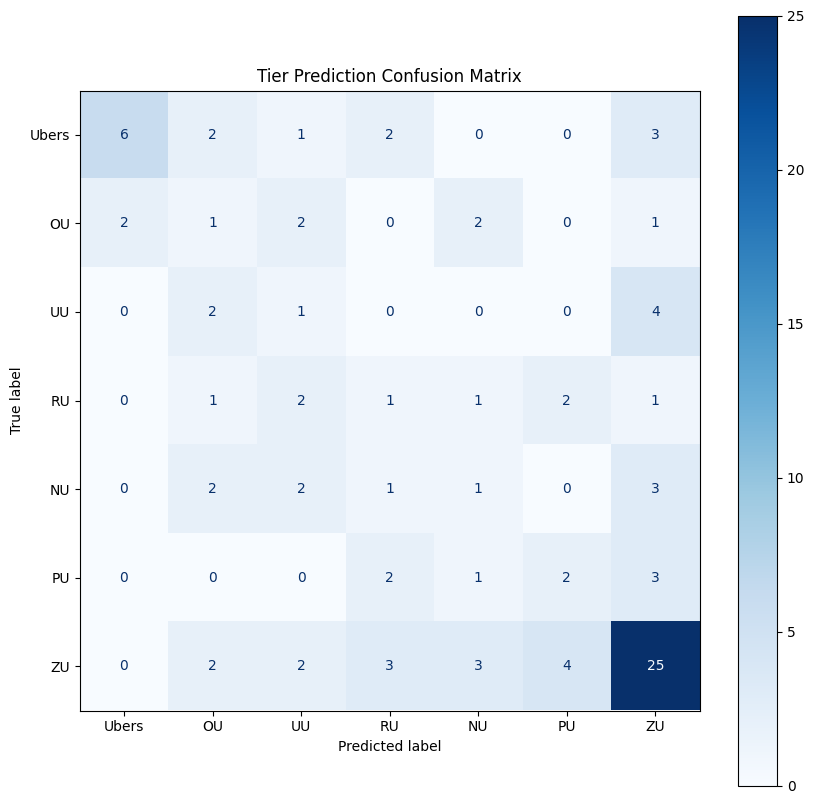

In [42]:
draw_conf_maxtrix(y_holdout, preds)